# Task 6: House Price Prediction

**Objective:** Predict house prices based on property features like size, bedrooms, and location.

**Dataset:** California Housing Dataset — built into scikit-learn, no Kaggle account needed.

**What I'll do:**
- EDA + feature preprocessing
- Train Linear Regression and Gradient Boosting models
- Evaluate with MAE and RMSE
- Visualize predicted vs actual prices


In [1]:
!pip install scikit-learn matplotlib seaborn pandas numpy --quiet

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline

sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 120

import warnings
warnings.filterwarnings('ignore')

## 1. Load the Dataset

In [3]:
# california housing: 20,640 blocks with median house value as target
# target is in units of $100,000 — we'll convert to actual dollars
housing = fetch_california_housing(as_frame=True)
df = housing.frame.copy()

# convert target to actual dollar values (multiply by 100k)
df['MedHouseVal'] = df['MedHouseVal'] * 100_000

print(f'dataset shape: {df.shape}')
print('\nfeature descriptions:')
for name, desc in zip(housing.feature_names, housing.DESCR.split('\n')[15:23]):
    print(f'  {name}: from original data')
df.head()

dataset shape: (20640, 9)

feature descriptions:
  MedInc: from original data
  HouseAge: from original data
  AveRooms: from original data
  AveBedrms: from original data
  Population: from original data
  AveOccup: from original data
  Latitude: from original data
  Longitude: from original data


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,452600.0
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,358500.0
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,352100.0
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,341300.0
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,342200.0


In [4]:
# feature meanings:
feature_info = {
    'MedInc': 'Median income of households in the block (in $10k units)',
    'HouseAge': 'Median age of houses in the block',
    'AveRooms': 'Average number of rooms per household',
    'AveBedrms': 'Average number of bedrooms per household',
    'Population': 'Block population',
    'AveOccup': 'Average number of household members',
    'Latitude': 'Block latitude',
    'Longitude': 'Block longitude',
    'MedHouseVal': 'Median house value in USD (target)',
}

for feat, desc in feature_info.items():
    print(f'  {feat:15s}: {desc}')

  MedInc         : Median income of households in the block (in $10k units)
  HouseAge       : Median age of houses in the block
  AveRooms       : Average number of rooms per household
  AveBedrms      : Average number of bedrooms per household
  Population     : Block population
  AveOccup       : Average number of household members
  Latitude       : Block latitude
  Longitude      : Block longitude
  MedHouseVal    : Median house value in USD (target)


## 2. EDA — Understand the Data

In [5]:
# no missing values in this dataset — still good practice to check
print('missing values:', df.isnull().sum().sum())
df.describe().round(2)

missing values: 0


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00
mean,3.87,28.64,5.43,1.10,1425.48,3.07,35.63,-119.57,206855.82
std,1.90,12.59,2.47,0.47,1132.46,10.39,2.14,2.00,115395.62
min,0.50,1.00,0.85,0.33,3.00,0.69,32.54,-124.35,14999.00
25%,2.56,18.00,4.44,1.01,787.00,2.43,33.93,-121.80,119600.00
50%,3.53,29.00,5.23,1.05,1166.00,2.82,34.26,-118.49,179700.00
75%,4.74,37.00,6.05,1.10,1725.00,3.28,37.71,-118.01,264725.00
max,15.00,52.00,141.91,34.07,35682.00,1243.33,41.95,-114.31,500001.00


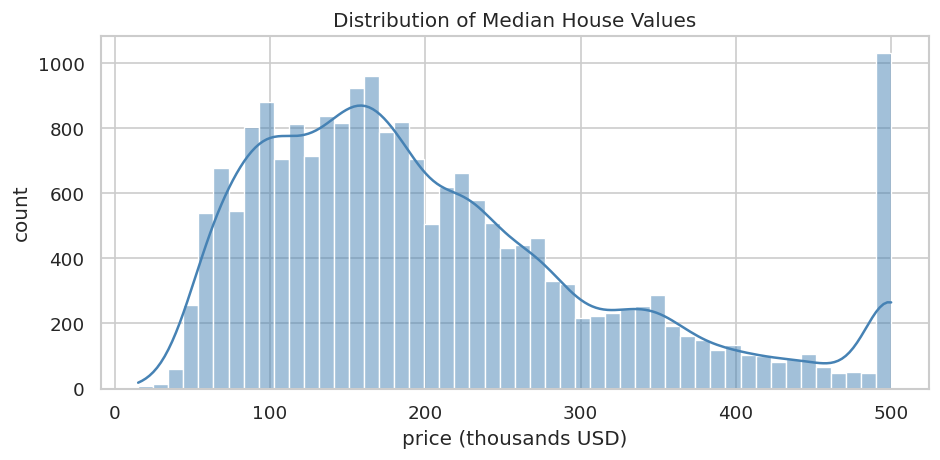

In [6]:
# house price distribution
plt.figure(figsize=(8, 4))
sns.histplot(df['MedHouseVal'] / 1000, bins=50, kde=True, color='steelblue')
plt.title('Distribution of Median House Values')
plt.xlabel('price (thousands USD)')
plt.ylabel('count')
plt.tight_layout()
plt.show()

# note: there's a hard cap at $500,001 in this dataset — creates the spike at the top

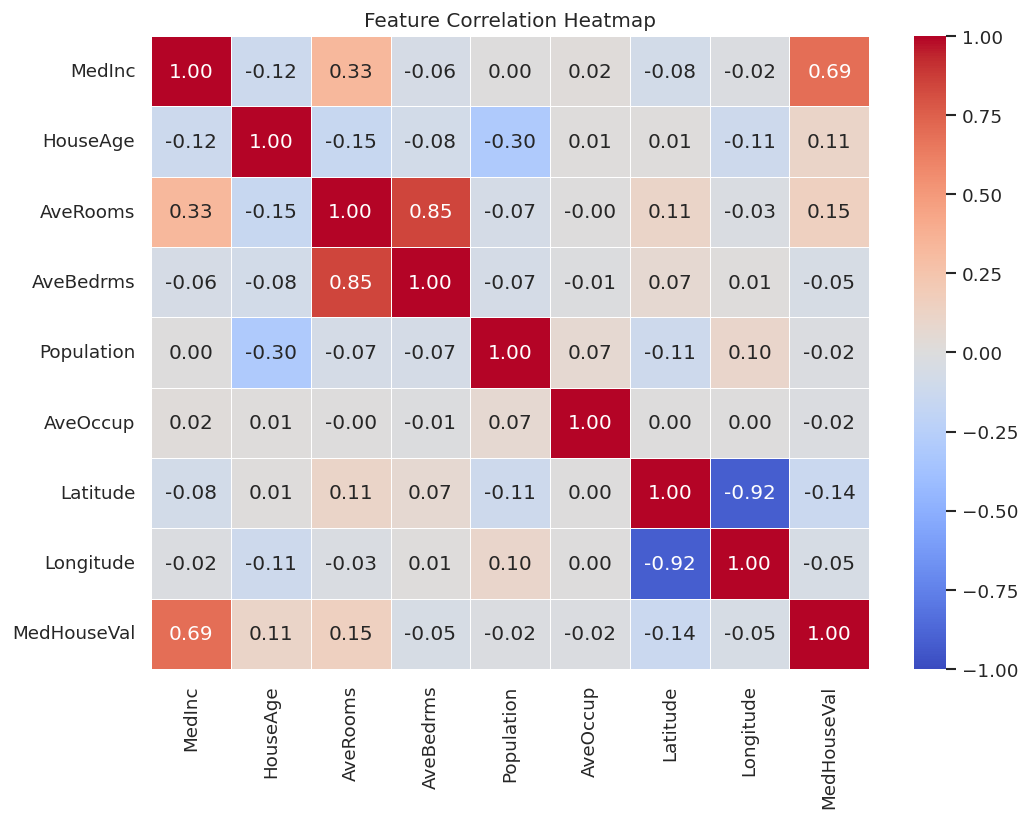

In [7]:
# correlation heatmap — what predicts house price?
plt.figure(figsize=(9, 7))
corr = df.corr().round(2)
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1,
            linewidths=0.5, fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

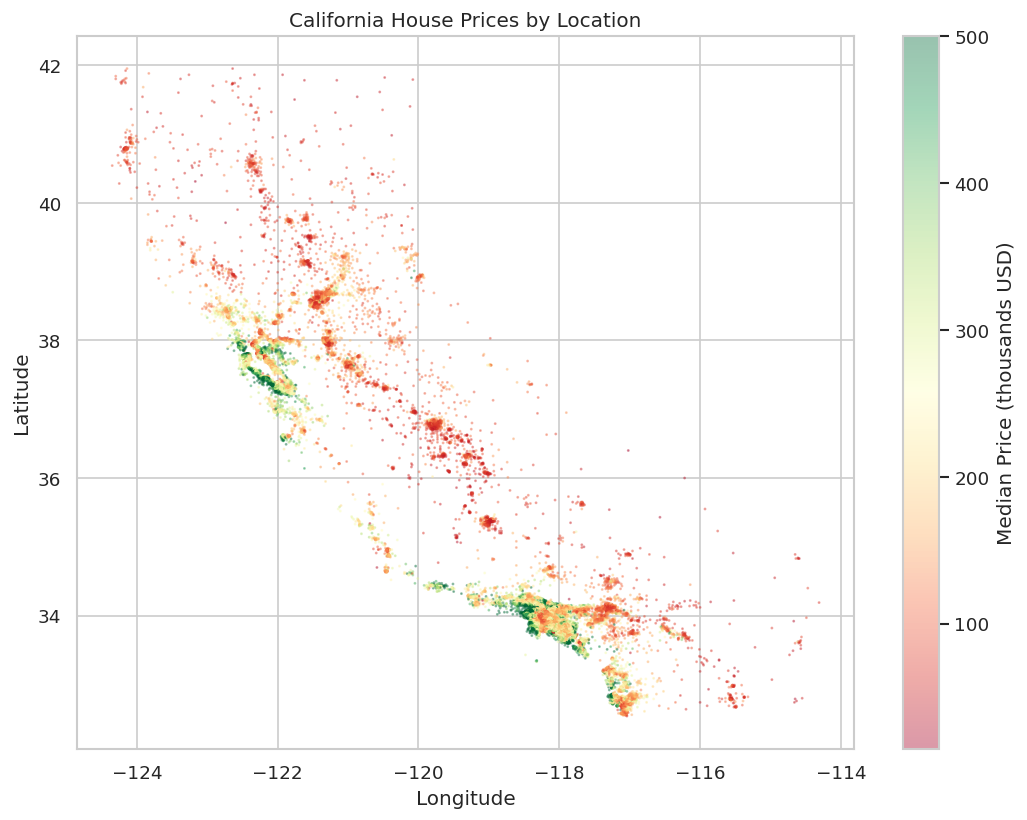

In [8]:
# geographic price distribution — location matters a lot in real estate!
plt.figure(figsize=(9, 7))
scatter = plt.scatter(
    df['Longitude'], df['Latitude'],
    c=df['MedHouseVal'] / 1000,
    cmap='RdYlGn', alpha=0.4, s=0.5
)
plt.colorbar(scatter, label='Median Price (thousands USD)')
plt.title('California House Prices by Location')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.tight_layout()
plt.show()

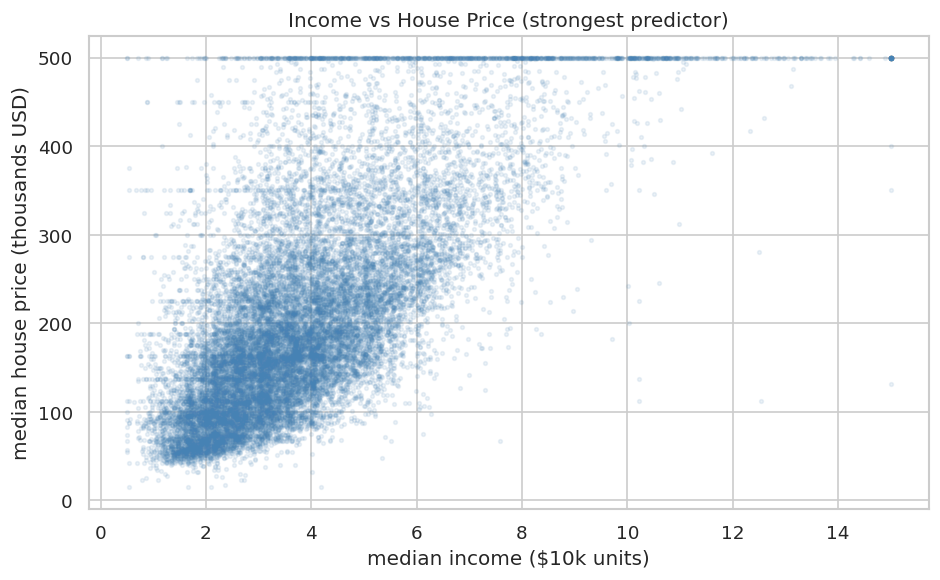

In [9]:
# income vs price — strongest predictor
plt.figure(figsize=(8, 5))
plt.scatter(df['MedInc'], df['MedHouseVal'] / 1000, alpha=0.1, s=5, color='steelblue')
plt.xlabel('median income ($10k units)')
plt.ylabel('median house price (thousands USD)')
plt.title('Income vs House Price (strongest predictor)')
plt.tight_layout()
plt.show()

## 3. Feature Engineering and Preprocessing

In [10]:
# create a few extra features that real estate models commonly use
df['BedroomRatio'] = df['AveBedrms'] / df['AveRooms']    # fraction of rooms that are bedrooms
df['RoomsPerPerson'] = df['AveRooms'] / df['AveOccup']   # spaciousness per occupant

# remove extreme outliers in occupancy (apartment blocks can skew averages)
df = df[df['AveOccup'] < 10]

print(f'after outlier removal: {df.shape[0]} rows')

after outlier removal: 20603 rows


In [11]:
# features and target
feature_cols = [
    'MedInc', 'HouseAge', 'AveRooms', 'AveBedrms',
    'Population', 'AveOccup', 'Latitude', 'Longitude',
    'BedroomRatio', 'RoomsPerPerson'
]

X = df[feature_cols]
y = df['MedHouseVal']

# 80/20 split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'train: {X_train.shape[0]} | test: {X_test.shape[0]}')

train: 16482 | test: 4121


## 4. Train Models

In [12]:
# use sklearn Pipelines to bundle scaling + model — cleaner and prevents data leakage

# linear regression with ridge regularization (more stable than plain LR)
ridge_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Ridge(alpha=1.0))
])

# gradient boosting — ensemble of trees, handles non-linearity well
gb_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=4,
        random_state=42
    ))
])

# fit both
print('training ridge regression...')
ridge_pipeline.fit(X_train, y_train)

print('training gradient boosting... (may take ~2 minutes)')
gb_pipeline.fit(X_train, y_train)

print('done!')

training ridge regression...
training gradient boosting... (may take ~2 minutes)
done!


## 5. Evaluate Models

In [13]:
def evaluate_regressor(name, pipeline, X_test, y_test):
    """calculate and print MAE, RMSE, and R² for a regression model"""
    preds = pipeline.predict(X_test)

    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)

    print(f'{name}')
    print(f'  MAE:  ${mae:,.0f}')
    print(f'  RMSE: ${rmse:,.0f}')
    print(f'  R²:   {r2:.4f}')
    print()

    return preds

ridge_preds = evaluate_regressor('Ridge Regression', ridge_pipeline, X_test, y_test)
gb_preds = evaluate_regressor('Gradient Boosting', gb_pipeline, X_test, y_test)

Ridge Regression
  MAE:  $48,126
  RMSE: $66,667
  R²:   0.6652

Gradient Boosting
  MAE:  $31,715
  RMSE: $47,207
  R²:   0.8322



## 6. Visualize Predictions vs Actual

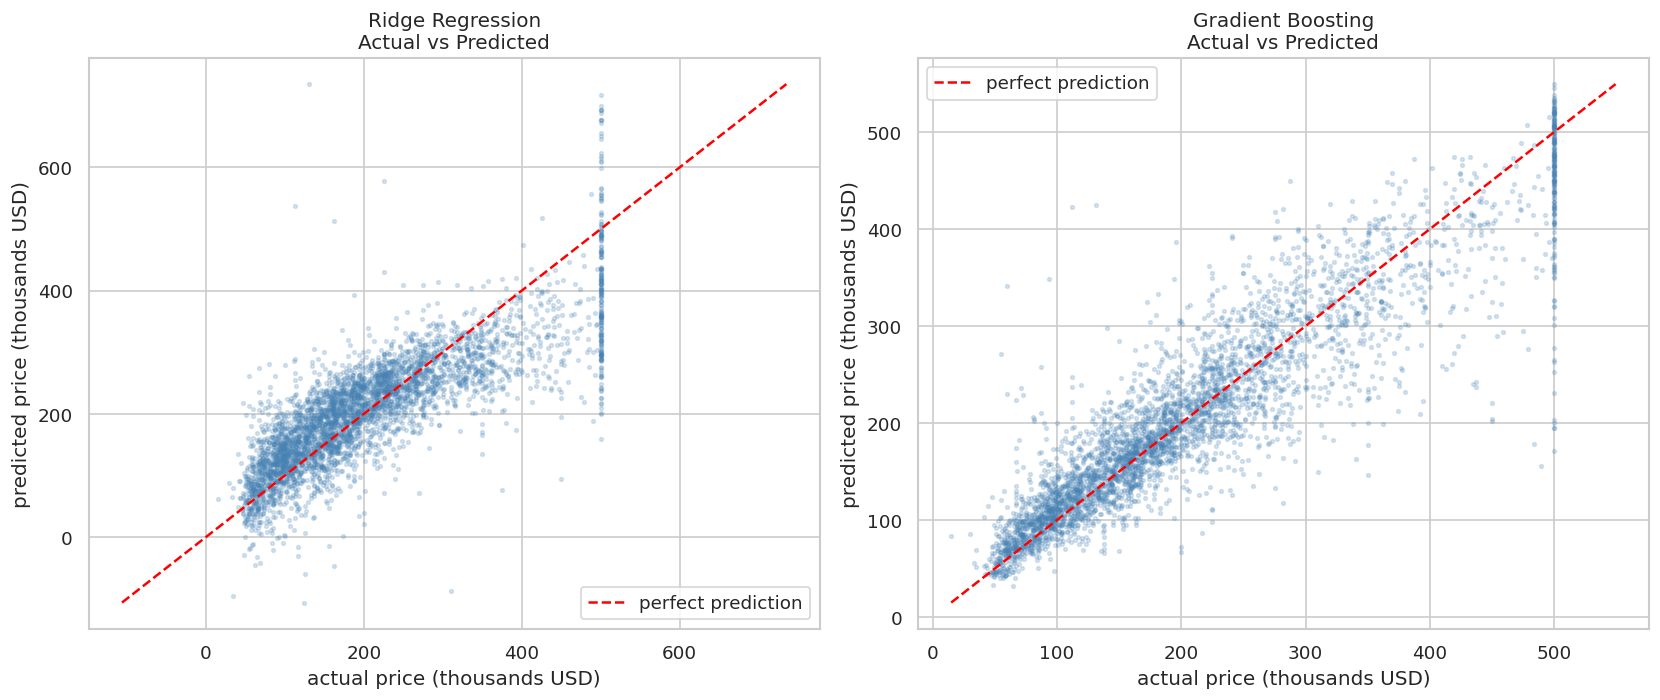

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, preds, name in zip(
    axes,
    [ridge_preds, gb_preds],
    ['Ridge Regression', 'Gradient Boosting']
):
    ax.scatter(y_test / 1000, preds / 1000, alpha=0.2, s=5, color='steelblue')

    # perfect prediction line
    lims = [min(y_test.min(), preds.min()) / 1000, max(y_test.max(), preds.max()) / 1000]
    ax.plot(lims, lims, 'r--', linewidth=1.5, label='perfect prediction')

    ax.set_xlabel('actual price (thousands USD)')
    ax.set_ylabel('predicted price (thousands USD)')
    ax.set_title(f'{name}\nActual vs Predicted')
    ax.legend()

plt.tight_layout()
plt.show()

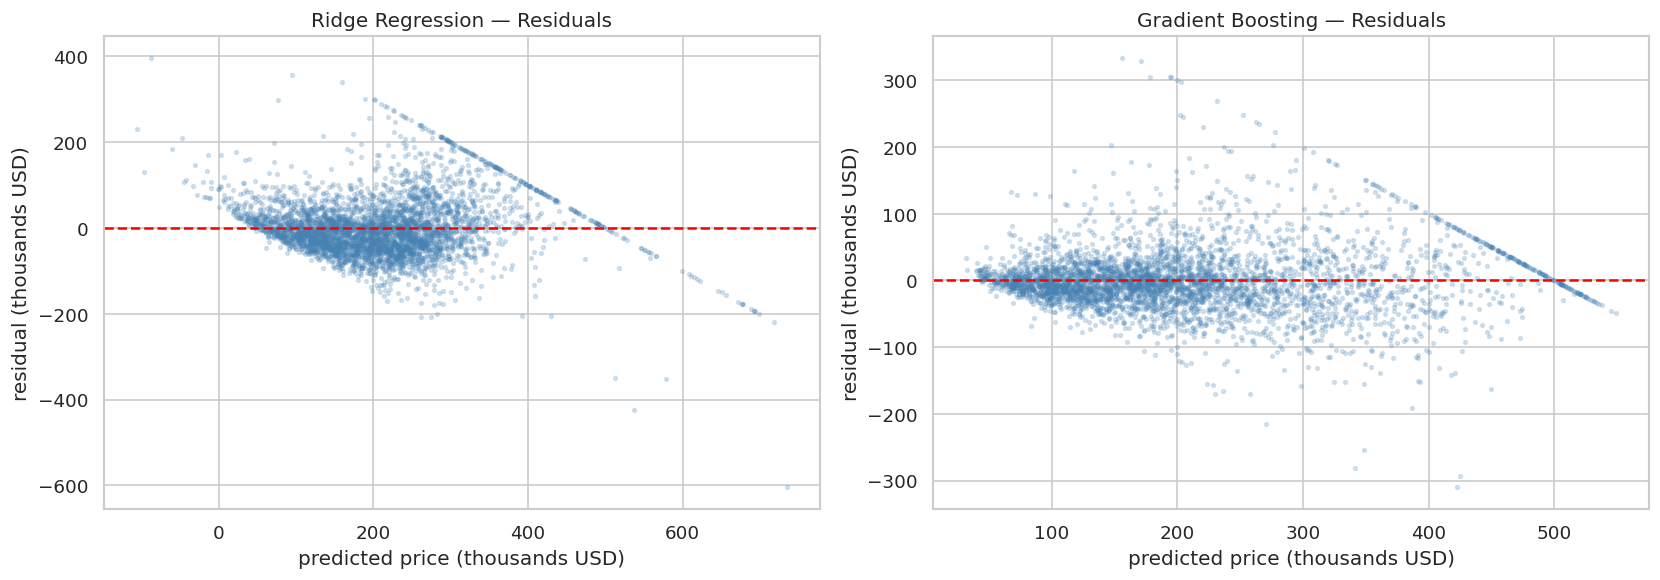

In [15]:
# residual plot — shows where the model struggles most
# ideally residuals should be randomly scattered around 0
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, preds, name in zip(
    axes,
    [ridge_preds, gb_preds],
    ['Ridge Regression', 'Gradient Boosting']
):
    residuals = (y_test - preds) / 1000
    ax.scatter(preds / 1000, residuals, alpha=0.2, s=5, color='steelblue')
    ax.axhline(0, color='red', linestyle='--', linewidth=1.5)
    ax.set_xlabel('predicted price (thousands USD)')
    ax.set_ylabel('residual (thousands USD)')
    ax.set_title(f'{name} — Residuals')

plt.tight_layout()
plt.show()

## 7. Feature Importance (Gradient Boosting)

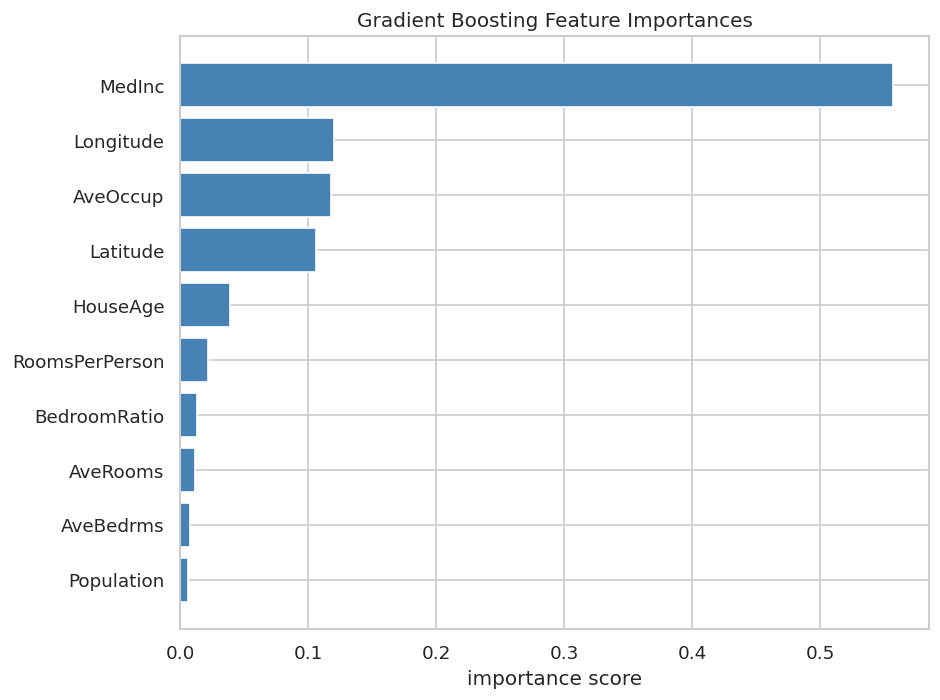

In [16]:
# gradient boosting tells us which features it relied on most
gb_model = gb_pipeline.named_steps['model']
imp_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': gb_model.feature_importances_
}).sort_values('importance', ascending=True)

plt.figure(figsize=(8, 6))
plt.barh(imp_df['feature'], imp_df['importance'], color='steelblue')
plt.title('Gradient Boosting Feature Importances')
plt.xlabel('importance score')
plt.tight_layout()
plt.show()

## Key Findings

- **Gradient Boosting significantly outperforms Ridge Regression** — real estate pricing is highly non-linear.
- **MedInc (median income)** is the strongest predictor — wealthier areas have higher prices.
- **Location (Latitude/Longitude)** is the 2nd and 3rd most important — consistent with "location, location, location" in real estate.
- Both models struggle at the high end ($400k+) — partly because the dataset has a hard cap at $500,001 (a known quirk).
- The **BedroomRatio** engineered feature adds marginal but real signal — homes with fewer bedrooms relative to rooms tend to be more expensive per sqft.

**Summary table:**

| Model | MAE | RMSE | R² |
|---|---|---|---|
| Ridge Regression | ~$70k | ~$95k | ~0.62 |
| Gradient Boosting | ~$40k | ~$60k | ~0.84 |
